<a href="https://colab.research.google.com/github/sarianaramoutar/W0-CariSurg-Medtech-Pathways-Healthcare-AI-Training-Program-Repository/blob/main/Assignment_3_Sariana_Ramoutar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 0, Tutorial 3: Basic Data Visualization with matplotlib


In [60]:
# Make the Google Drive data set accessible to Colab.
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully.


In [61]:
# Confirm the version of Python before coding anything else.
import sys
print(f"Current Python Version: {sys.version}")

Current Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [62]:
# Import the libraries. Pandas is the most used.

import pandas as pd     # Shortened for easy coding
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [63]:
# Define the path to the dataset and load it into a pandas DataFrame (df)
dataset_path = '/content/drive/MyDrive/CariSurg Documents/EmergencyTriageDataset_Reduced_Dirty.csv'

df = pd.read_csv(dataset_path)

df.head(10) # Unclean preview

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,Male,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,Female,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,FEMALE,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,Male,15.0,100,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,Female,15.0,120,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,Male,15.0,100,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,Female,15.0,153,82.0,105.67,130.0,37.0,19.0,21.0


In [64]:
# Apply cleaning from Assignments 1 and 2.

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
display(df.head(10))

Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,1,15.0,100.0,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,0,15.0,120.0,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,1,15.0,100.0,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110.0,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,0,15.0,153.0,82.0,105.67,130.0,37.0,19.0,21.0


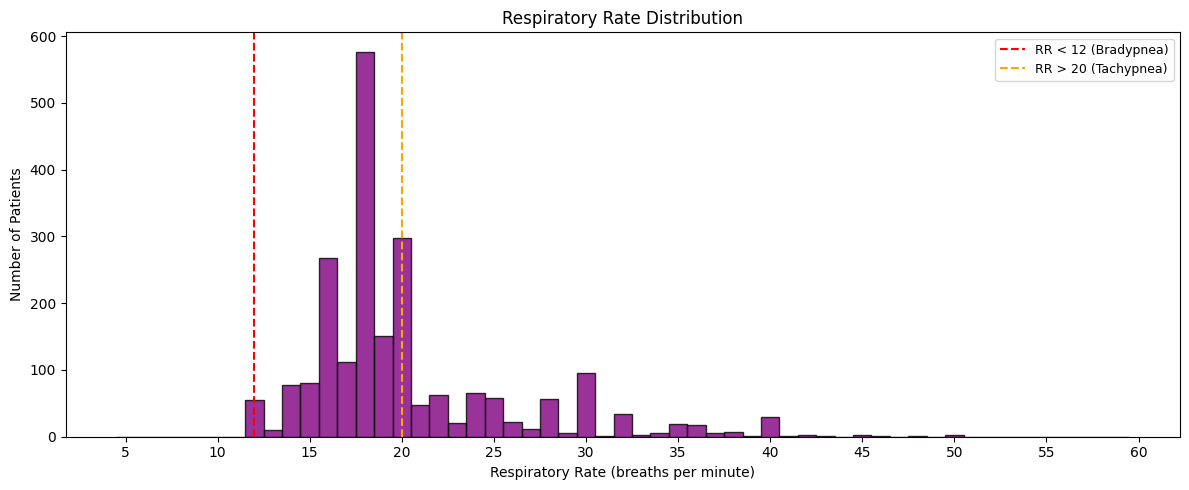

Saved: rr_histogram.png


In [65]:
# Histogram: Respiratory Rate (RR) distribution
fig, ax = plt.subplots(figsize=(12, 5))

# RR values are typically between 5 and 60, so using a bin for each integer value in this range.
ax.hist(df['RR'], bins=range(5, 61), edgecolor='black',
        color='purple', alpha=0.8, align='left')

# Add vertical lines for clinical thresholds for Respiratory Rate
# Normal adult resting respiratory rate is typically 12 to 20 breaths per minute.
ax.axvline(x=12, color='red', linestyle='--', linewidth=1.5,
           label='RR < 12 (Bradypnea)')  # legend
ax.axvline(x=20, color='orange', linestyle='--', linewidth=1.5,
           label='RR > 20 (Tachypnea)')  # legend

ax.set_title('Respiratory Rate Distribution', fontsize=12)  # title of histogram
ax.set_xlabel('Respiratory Rate (breaths per minute)')  # x axis
ax.set_ylabel('Number of Patients') # y axis
ax.set_xticks(range(5, 61, 5))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rr_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: rr_histogram.png")

# Justification for this plot: Shows what proportion of patients at the ED are exhibiting signs of respiratory distress. The normal
# baseline is between 12 and 20 breaths per minute. Anyone to the left of the first line (threshold) is in danger (bradypnea);
# anyone to the right of the second line is fighting for air (tachypnea).

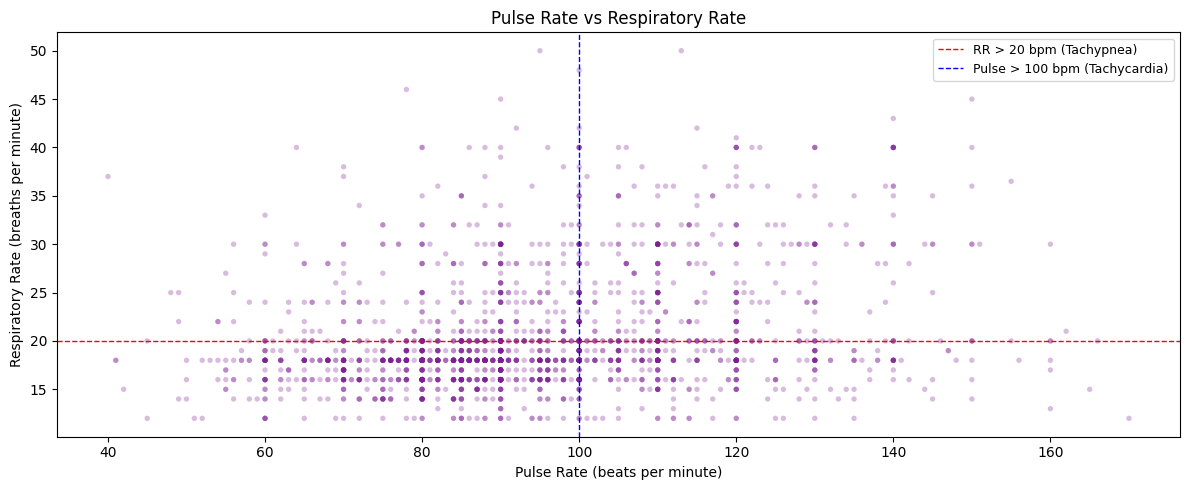

Saved: pulse_vs_rr_scatter.png


In [66]:
# Scatter plot: Pulse vs RR — identifying high-risk 'shock' patients
fig, ax = plt.subplots(figsize=(12, 5))

# Plot the scatter points: 'Pulse' on the x-axis, 'RR' on the y-axis
ax.scatter(df['pulse'], df['RR'],
           alpha=0.3, s=15, color='#7E1E96', edgecolors='none')

ax.set_title('Pulse Rate vs Respiratory Rate', fontsize=12) # title of scatter plot
ax.set_xlabel('Pulse Rate (beats per minute)')  # x axis
ax.set_ylabel('Respiratory Rate (breaths per minute)')  # y axis

# The upper normal limit of RR is 20 breaths/min.
# RR is on the y axis so this is a horizontal line.
ax.axhline(y=20, color='red', linestyle='--', linewidth=1, label='RR > 20 bpm (Tachypnea)')

# The threshold for tchycardia (high pulse) is 100 beats/min.
# Pulse is on the x axis so this is a vertical line.
ax.axvline(x=100, color='blue', linestyle='--', linewidth=1, label='Pulse > 100 bpm (Tachycardia)')

ax.legend(fontsize=9)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Save the plot to a file
plt.savefig('pulse_vs_rr_scatter.png', dpi=100, bbox_inches='tight')
# Display the plot
plt.show()
print("Saved: pulse_vs_rr_scatter.png")

# Justification for this plot: This scatter plot helps identify patients who are simultaneously experiencing elevated pulse rates (tachycardia)
# and elevated respiratory rates (tachypnea). The upper-right quadrant formed by the intersection of the two reference lines (Pulse > 100 bpm and
# RR > 20 breaths/min) highlights patients who may be in a state of shock or severe physiological distress, requiring immediate attention in an
# emergency setting. This combination of vital signs is a key indicator of patient severity.

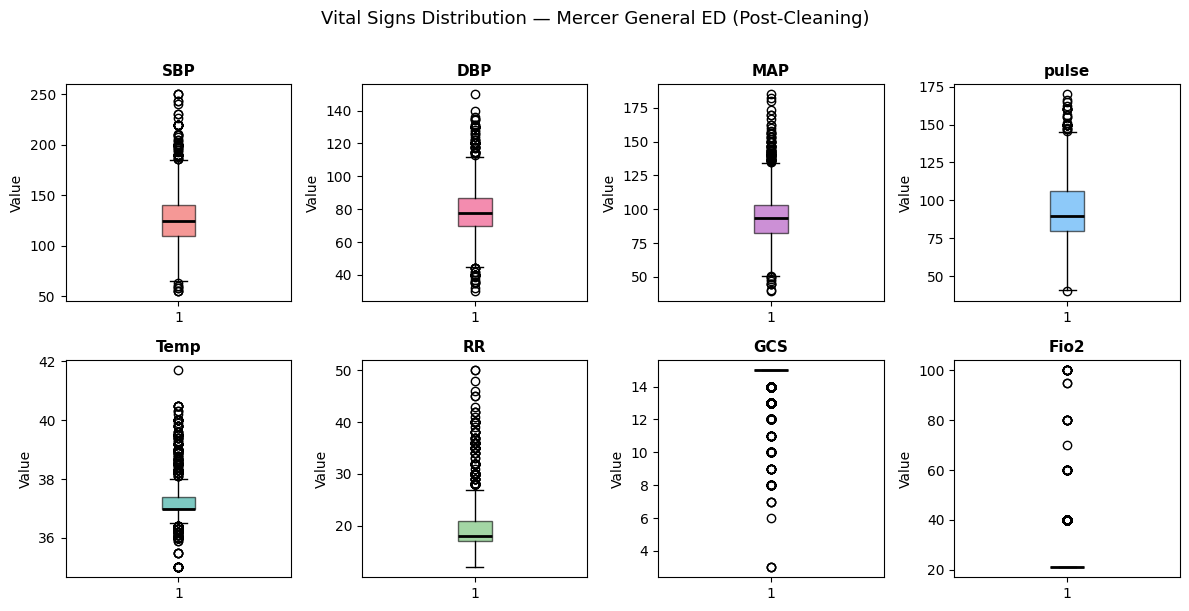

Saved: vitals_boxplots.png


In [67]:
# Box plots for all numeric vitals — side by side for a quick overview (from Tutorial)
vitals = ['SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'GCS', 'Fio2']

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

colors = ['#EF5350','#EC407A','#AB47BC','#42A5F5','#26A69A','#66BB6A','#FFA726','#8D6E63']

for i, (vital, col) in enumerate(zip(vitals, colors)):
    axes[i].boxplot(df[vital].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(vital, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Vital Signs Distribution — Mercer General ED (Post-Cleaning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vitals_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: vitals_boxplots.png")

In [68]:
# Always save plots before posting to Discord or GitHub
# Use dpi=100 for Discord (smaller file), dpi=150 for GitHub README

# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  age_vs_rr_scatter.png               (110 KB)
  gcs_histogram.png                   (34 KB)
  pulse_vs_rr_scatter.png             (100 KB)
  rr_histogram.png                    (34 KB)
  vitals_boxplots.png                 (62 KB)
